In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import (
    PermutationLpModel,
    exclude_current_solution,
    exclude_largest_variable,
    exclude_current_solution_bigm
)

# Exclusion cuts: enumerating multiple distinct solutions

`LpModel.add_constraint(fn)` registers an extra constraint-adding callable that
`build()` applies on top of the winner constraints (via `model._apply_extra_constraints()`).

`exclude_current_solution(model)` builds one such cut from the model's *current*
solution: it forces at least one previously-unused ranking/region to be used,
guaranteeing the next `solve()` returns a structurally different voter placement.

In [3]:
positions = [(-5, -5), (2, -3), (1, 2), (-2, 7), (7, 6)]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

strategies = [PluralityStrategy(), BordaCountStrategy()]

winners = {
    PluralityStrategy.key: 3,
    BordaCountStrategy.key: 1,
}

N_VOTERS = 1000

model = PermutationLpModel(
    candidates=candidates,
    n_voters=N_VOTERS,
    winners=winners,
    objective="minmax",
)
print(model.solve())

Optimal


iteration 0: Optimal, 1000 voters


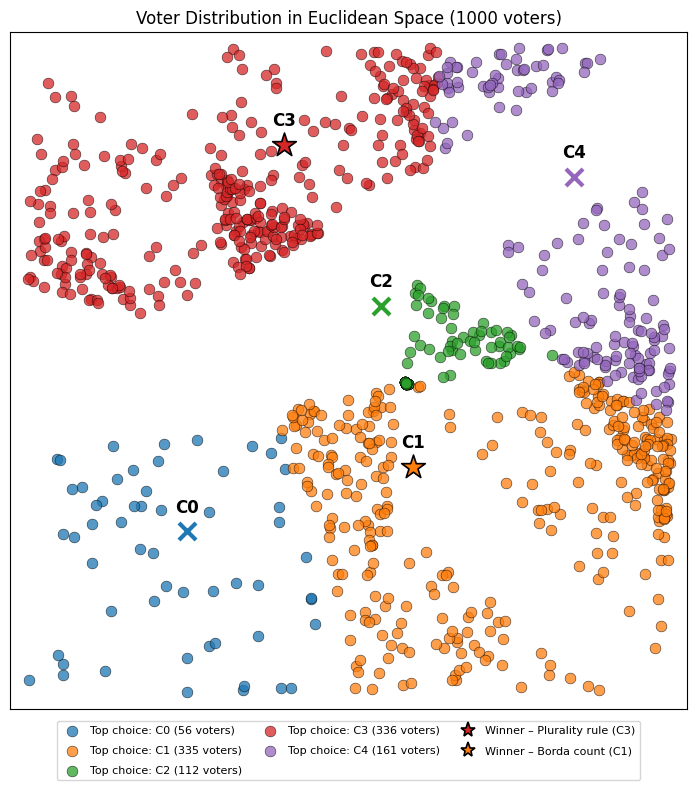

iteration 1: Optimal, 1000 voters


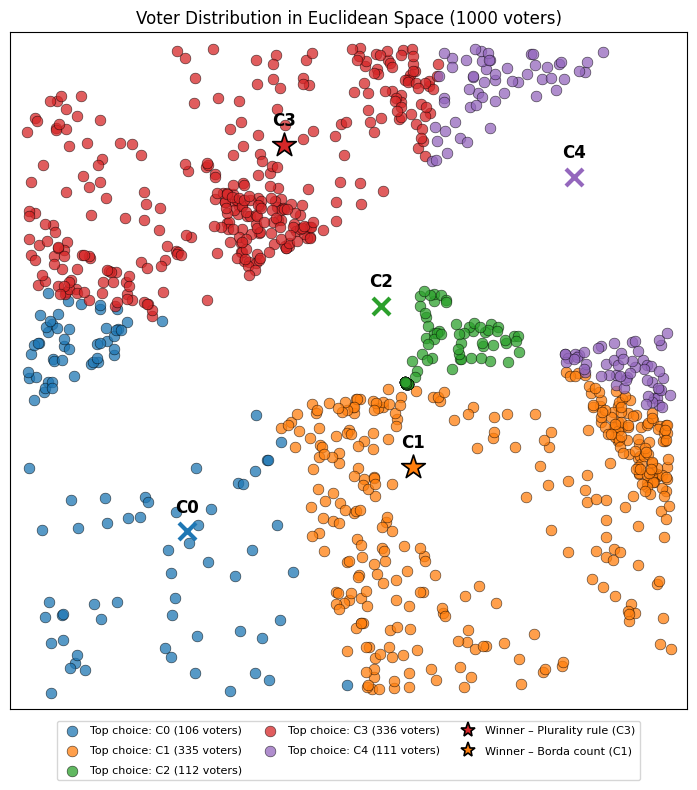

iteration 2: Optimal, 1000 voters


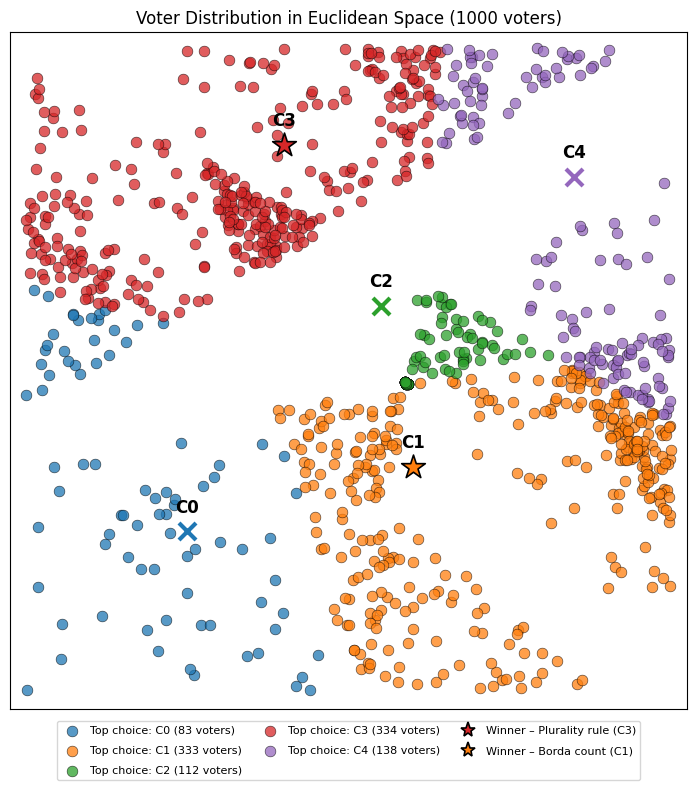

iteration 3: Optimal, 1000 voters


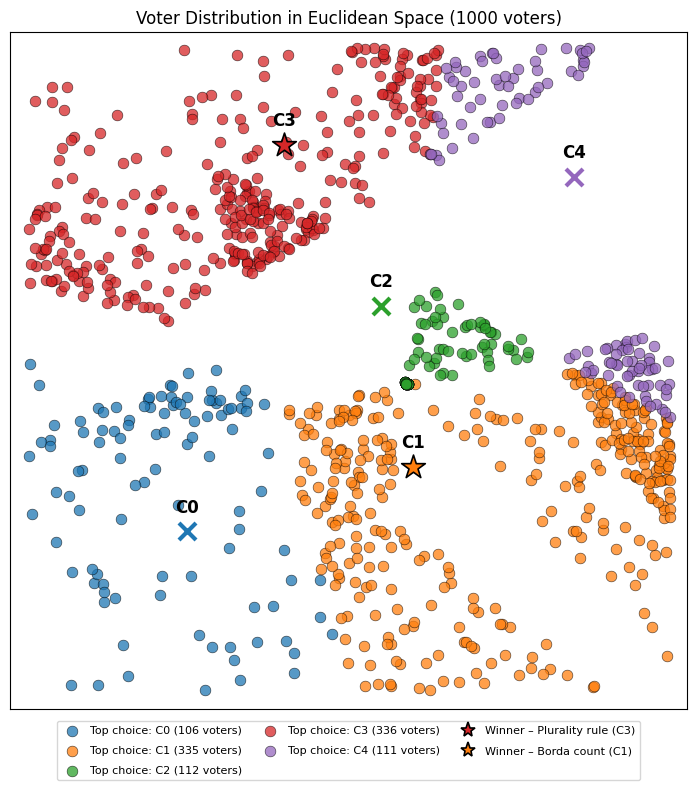

iteration 4: Optimal, 1000 voters


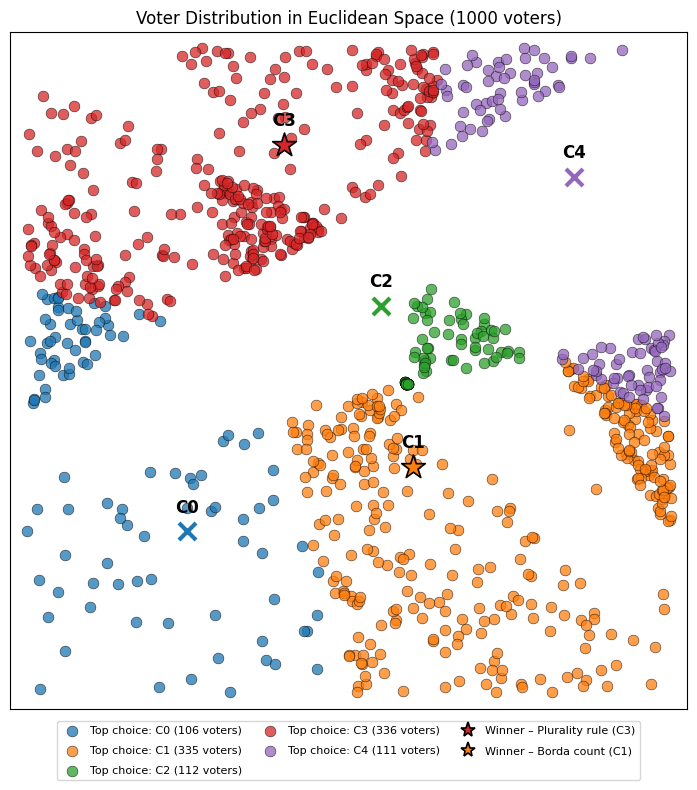

In [4]:
# Enumerate a handful of distinct feasible voter placements for the same `winners`,
# by adding an exclusion cut after each solve and rebuilding before the next.
solutions = []

n_solutions = 5
for i in range(n_solutions):
    status = model.solve()
    if status != "Optimal":
        print(f"iteration {i}: {status} - stopping")
        break

    positions_i = model.generate_voter_positions()
    solutions.append(positions_i)
    print(f"iteration {i}: {status}, {len(positions_i)} voters")
    plot_lp_result(candidates, positions_i, winners)

    model.add_constraint(exclude_current_solution(model, min_new_voters=50))
    # model.add_constraint(exclude_largest_variable(model))
    model.build()

In [5]:
# Sanity check: each solution differs from every other (no duplicate voter sets),
# and each one independently reproduces the target winners.
for i, pos_i in enumerate(solutions):
    voters_i = [Voter(position=p) for p in pos_i]
    result_i = Election(candidates=candidates, voters=voters_i).compare_strategies(
        strategies
    )
    actual = {s.key: candidates.index(result_i.winner(s)) for s in strategies}
    print(f"solution {i}: {len(pos_i)} voters, winners={actual}, target={winners}")
    assert actual == winners

for i in range(len(solutions)):
    for j in range(i + 1, len(solutions)):
        same_len = len(solutions[i]) == len(solutions[j])
        same_points = same_len and np.allclose(
            np.sort(solutions[i], axis=0), np.sort(solutions[j], axis=0)
        )
        assert not same_points, f"solutions {i} and {j} are identical"

print("\nAll solutions valid and pairwise distinct.")

solution 0: 1000 voters, winners={'plurality': 3, 'borda': 1}, target={'plurality': 3, 'borda': 1}
solution 1: 1000 voters, winners={'plurality': 3, 'borda': 1}, target={'plurality': 3, 'borda': 1}
solution 2: 1000 voters, winners={'plurality': 3, 'borda': 1}, target={'plurality': 3, 'borda': 1}
solution 3: 1000 voters, winners={'plurality': 3, 'borda': 1}, target={'plurality': 3, 'borda': 1}
solution 4: 1000 voters, winners={'plurality': 3, 'borda': 1}, target={'plurality': 3, 'borda': 1}

All solutions valid and pairwise distinct.


In [6]:
positions = [(-5, -5), (2, -3), (1, 2), (-2, 7), (7, 6)]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

strategies = [PluralityStrategy(), BordaCountStrategy()]

winners = {
    PluralityStrategy.key: 3,
    BordaCountStrategy.key: 1,
}

N_VOTERS = 1000

model = PermutationLpModel(
    candidates=candidates,
    n_voters=N_VOTERS,
    winners=winners,
    objective="minmax",
)
print(model.solve())

Optimal


iteration 0: Optimal, 1000 voters


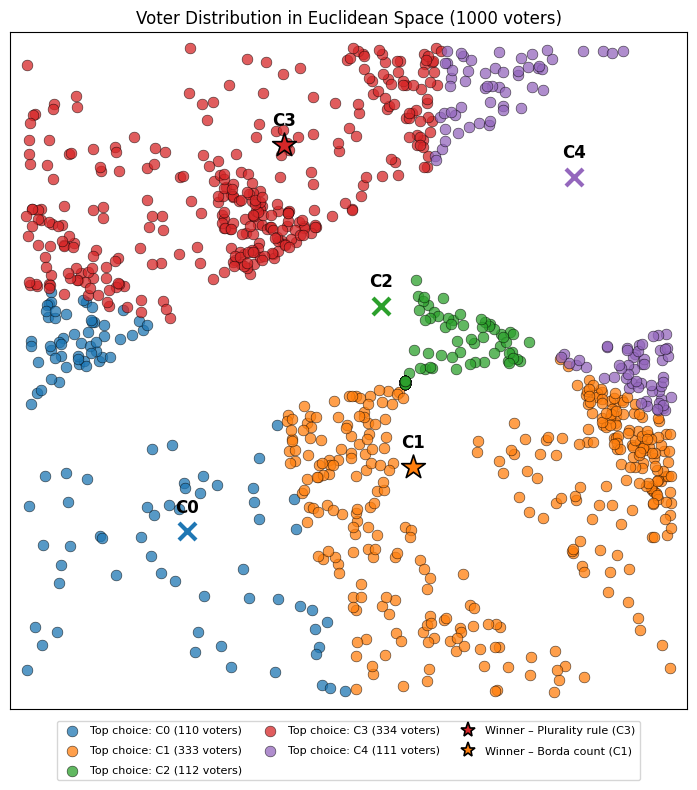

iteration 1: Optimal, 1000 voters


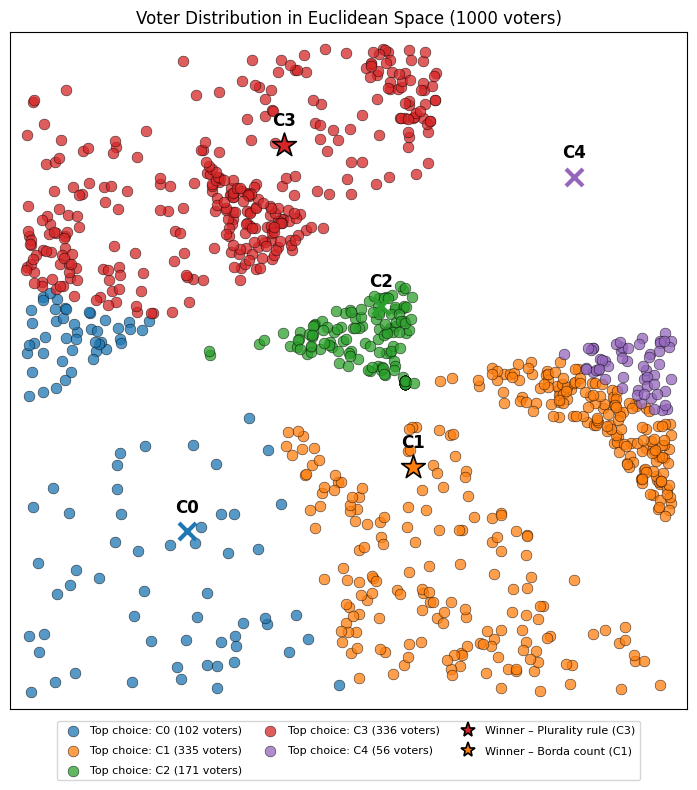

iteration 2: Optimal, 1000 voters


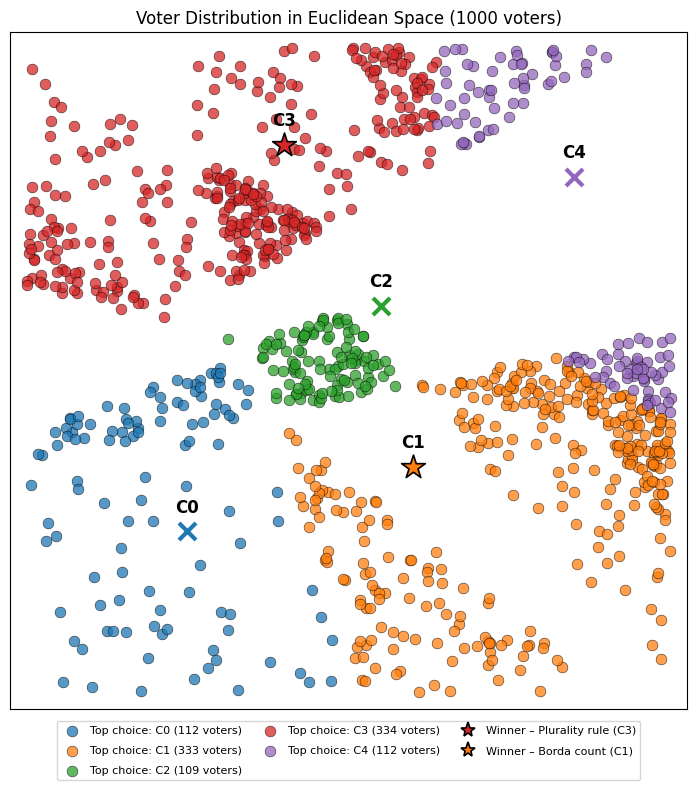

iteration 3: Optimal, 1000 voters


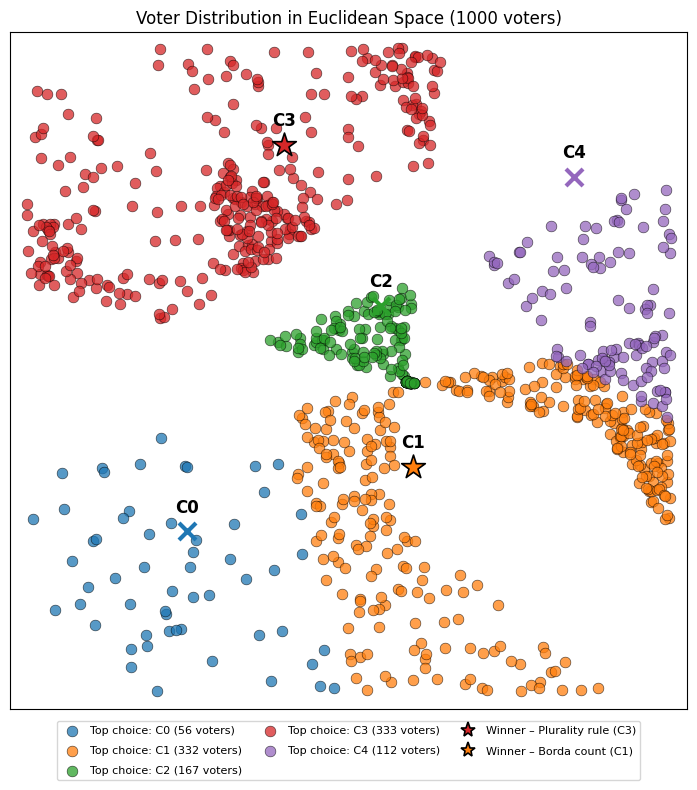

iteration 4: Optimal, 1000 voters


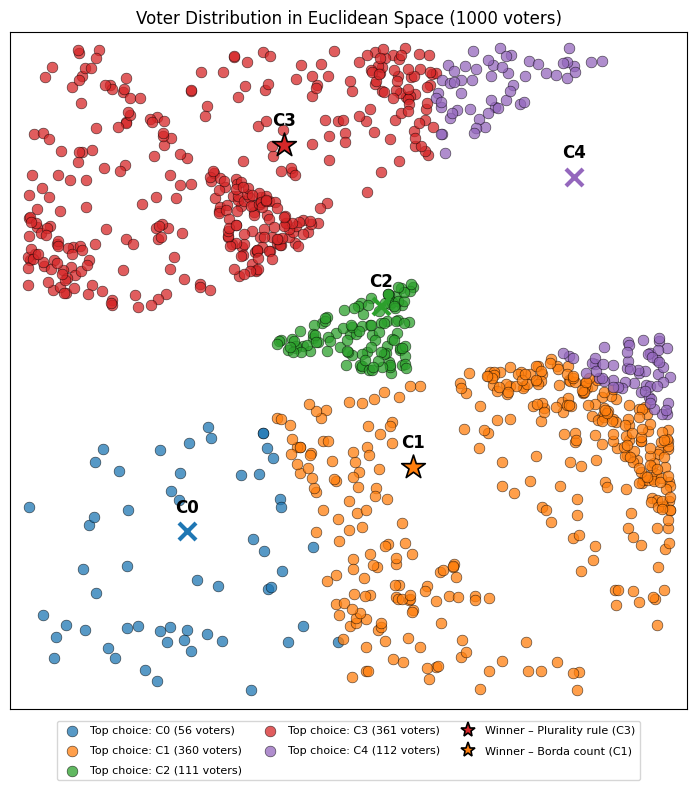

In [7]:
# Enumerate a handful of distinct feasible voter placements for the same `winners`,
# by adding an exclusion cut after each solve and rebuilding before the next.
solutions = []

n_solutions = 5
for i in range(n_solutions):
    status = model.solve()
    if status != "Optimal":
        print(f"iteration {i}: {status} - stopping")
        break

    positions_i = model.generate_voter_positions()
    solutions.append(positions_i)
    print(f"iteration {i}: {status}, {len(positions_i)} voters")
    plot_lp_result(candidates, positions_i, winners)

    model.add_constraint(exclude_current_solution_bigm(model))
    # model.add_constraint(exclude_largest_variable(model))
    model.build()